In [1]:
#!pip install jax[cuda12-local]
#!pip install diffrax
#!pip install PythonicDISORT

In [2]:
%matplotlib inline
import os
#os.environ["PYDISORT_RICCATI_JAX_X64"] = "1"
import jax.numpy as jnp
import matplotlib.pyplot as plt
plt_default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
# Absorbing atmosphere (SWIR-like: omega < 1 gives deep-cloud sensitivity)
tau_bot   = 20
omega_top = 0.96
omega_bot = 0.85
g_top     = 0.865
g_bot     = 0.820

In [4]:
omega_func = lambda tau: (
    omega_top + (omega_bot - omega_top) * (tau / tau_bot)   # background
)

g_func = lambda tau: (
    g_top + (g_bot - g_top) * (tau / tau_bot)               # background
)

# --- Spike parameters (near ToA) ---
tau_spike = 2.0
sigma     = 0.5
delta_g   = 0.04
delta_o   = -0.04

omega_func_spike = lambda tau: (
    omega_top + (omega_bot - omega_top) * (tau / tau_bot)
    + delta_o * jnp.exp(-0.5 * ((tau - tau_spike) / sigma) ** 2)
)

g_func_spike = lambda tau: (
    g_top + (g_bot - g_top) * tau / tau_bot
    + delta_g * jnp.exp(-0.5 * ((tau - tau_spike) / sigma) ** 2)
)

In [5]:
tau_plot = jnp.linspace(0, tau_bot, 300)

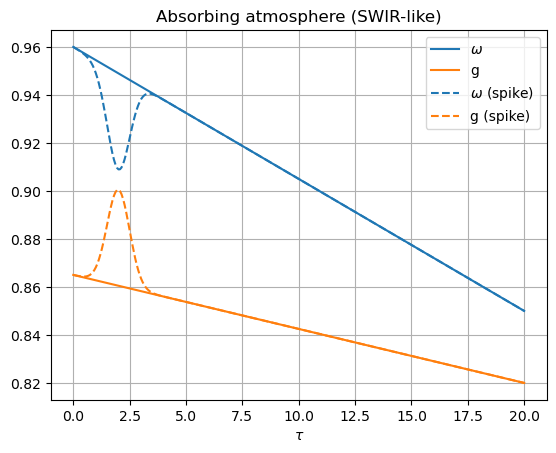

In [6]:
plt.plot(tau_plot, omega_func(tau_plot), label=r"$\omega$", color=plt_default_colors[0])
plt.plot(tau_plot, g_func(tau_plot), label="g", color=plt_default_colors[1])
plt.plot(tau_plot, omega_func_spike(tau_plot), "--", label=r"$\omega$ (spike)", color=plt_default_colors[0])
plt.plot(tau_plot, g_func_spike(tau_plot), "--", label="g (spike)", color=plt_default_colors[1])
plt.xlabel(r"$\tau$")
plt.title("Absorbing atmosphere (SWIR-like)")
plt.legend()
plt.grid()

# Call solver

In [7]:
import sys
from pathlib import Path

repo_root = Path.cwd()  # or Path("path/to/repo") if cwd isn't the repo root
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "tests"))

from pydisort_riccati_jax import pydisort_riccati_jax

In [8]:
mu0, I0, phi0 = 0.5, 1.0, 0.0
NQuad = 16
NLeg = NQuad

Leg_coeffs_func = lambda tau: g_func(tau) ** jnp.arange(NLeg)
_, _, _, _, tau_grid = pydisort_riccati_jax(
    tau_bot, omega_func, Leg_coeffs_func, NQuad, mu0, I0, phi0,
    tol=1e-3,
)

Leg_coeffs_func_spike = lambda tau: g_func_spike(tau) ** jnp.arange(NLeg)
_, _, _, _, tau_grid_spike = pydisort_riccati_jax(
    tau_bot, omega_func_spike, Leg_coeffs_func_spike, NQuad, mu0, I0, phi0,
    tol=1e-3,
)

In [9]:
len(tau_grid)

39

In [10]:
len(tau_grid_spike)

60

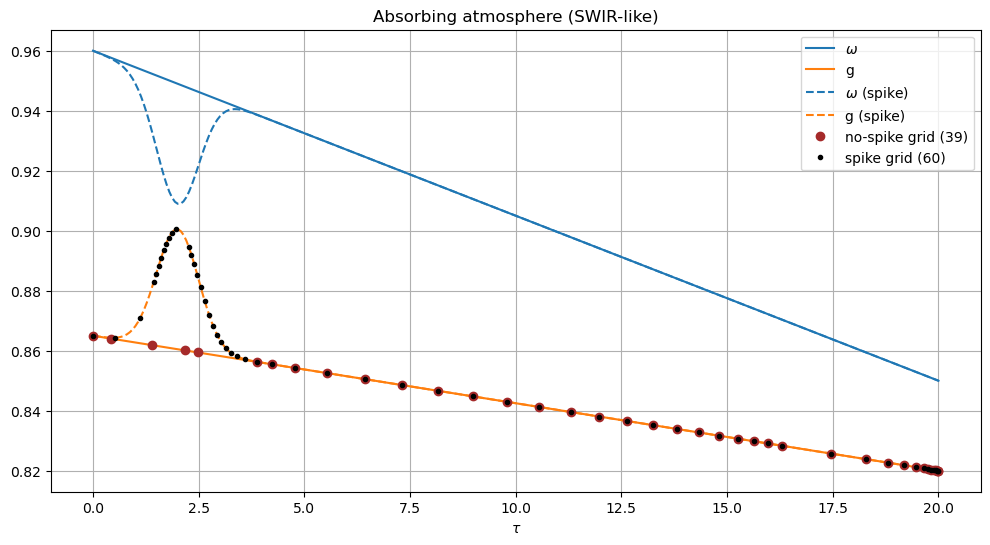

In [11]:
plt.figure(figsize=(12,6))
plt.plot(tau_plot, omega_func(tau_plot), label=r"$\omega$", color=plt_default_colors[0])
plt.plot(tau_plot, g_func(tau_plot), label="g", color=plt_default_colors[1])
plt.plot(tau_plot, omega_func_spike(tau_plot), "--", label=r"$\omega$ (spike)", color=plt_default_colors[0])
plt.plot(tau_plot, g_func_spike(tau_plot), "--", label="g (spike)", color=plt_default_colors[1])

plt.plot(tau_grid, g_func(tau_grid), "o", color="brown", label=f"no-spike grid ({len(tau_grid)})")
plt.plot(tau_grid_spike, g_func_spike(tau_grid_spike), ".", color="black", label=f"spike grid ({len(tau_grid_spike)})")
plt.xlabel(r"$\tau$")
plt.title("Absorbing atmosphere (SWIR-like)")
plt.legend()
plt.grid()

# QRCP-trimmed tau grids

Compute the Jacobian $\partial u^+_\text{ToA} / \partial g$ for each Fourier mode via `jax.jacrev`, then sum with cosine weights to form the physical Jacobian at the principal plane ($\phi = \phi_0 = 0$). QRCP with forced boundaries selects the tau-grid points that capture the most sensitivity (threshold: $|R_{\text{diag}}| > 1\%$ of $|R_{\text{diag},0}|$).

In [12]:
import numpy as np
import jax
import time
from math import pi
import diffrax
from scipy.linalg import qr
from pathlib import Path

from _riccati_solver_jax import (
    _make_alpha_beta_funcs_jax,
    _make_q_funcs_jax,
)
from _solve_bc_riccati_jax import _solve_bc_riccati_jax
from pydisort_riccati_jax import _padded_legendre_modes
from PythonicDISORT import subroutines

N = NQuad // 2
NFourier = NQuad
I0_div_4pi = I0 / (4 * pi)
mu_arr_pos_np, W_np = subroutines.Gauss_Legendre_quad(N)
mu_arr_pos = jnp.array(mu_arr_pos_np)
W_jax = jnp.array(W_np)
M_inv = 1.0 / mu_arr_pos
tol = 1e-3

n_trim = 8

# Padded per-mode Legendre stacks at the static mu0 (same host-side build the
# solver's `riccati_setup` uses): weighted Pochhammer (NFourier, NLeg), the
# P_l^m(+/-mu_i) tables (NFourier, NLeg, N), and the static-mu0 table
# P_l^m(-mu0) (NFourier, NLeg). Rows l < m are pre-zeroed by the padding.
wp_modes, ap_pos_modes, ap_neg_modes, amu0_modes = _padded_legendre_modes(
    NFourier, NLeg, N, mu_arr_pos, mu0)


def _integrate(alpha_func, beta_func, sigma_end, q1_func, q2_func):
    def vf(sigma, state, args):
        R, T, s = state['R'], state['T'], state['s']
        alpha = alpha_func(sigma)
        beta = beta_func(sigma)
        A = alpha + R @ beta
        dR = alpha @ R + R @ alpha + R @ beta @ R + beta
        dT = A @ T
        ds = A @ s + R @ q1_func(sigma) + q2_func(sigma)
        return {'R': dR, 'T': dT, 's': ds}

    y0 = {'R': jnp.zeros((N, N)), 'T': jnp.eye(N), 's': jnp.zeros(N)}
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(vf), diffrax.Kvaerno5(),
        t0=0.0, t1=float(sigma_end), dt0=None, y0=y0,
        stepsize_controller=diffrax.PIDController(rtol=tol, atol=tol * 1e-3),
        saveat=diffrax.SaveAt(t1=True), max_steps=16384)
    return sol.ys['R'][0], sol.ys['T'][0], sol.ys['s'][0]


def compute_jacobian(omega_fn, g_fn, tau_grid_in, cache_path=None):
    """Compute physical Jacobian d(u_ToA)/d(g) at phi=phi0=0.

    Also computes d(u_ToA)/d(omega) if omega varies.
    Returns (tau_grid, J_g_phys, J_omega_phys_or_None).
    If cache_path is given, saves/loads results to skip recomputation.
    """
    if cache_path and Path(cache_path).exists():
        d = np.load(cache_path)
        J_omega = d['J_omega'] if 'J_omega' in d.files else None
        print(f"  Loaded from cache: {cache_path}")
        return d['tau_grid'], d['J_g'], J_omega

    tg = jnp.array(tau_grid_in)
    K = len(tg)
    zero_K = jnp.zeros(K)

    omega_vals = np.array([float(omega_fn(t)) for t in np.linspace(0, tau_bot, 50)])
    omega_varies = (omega_vals.max() - omega_vals.min()) > 1e-12

    def make_solve_m(m, wp_m, ap_pos_m, ap_neg_m, amu0_m):
        m_is_zero = float(m == 0)
        tb = float(tau_bot)

        def solve_m(delta_omega_vec, delta_g_vec):
            def omega_pert(tau):
                return omega_fn(tau) + jnp.interp(tau, tg, delta_omega_vec)
            def Leg_pert(tau):
                return (g_fn(tau) + jnp.interp(tau, tg, delta_g_vec)) ** jnp.arange(NLeg)
            alpha_f, beta_f = _make_alpha_beta_funcs_jax(
                omega_pert, Leg_pert, wp_m, ap_pos_m, ap_neg_m,
                W_jax, M_inv, N, NLeg)
            q_up, q_down = _make_q_funcs_jax(
                omega_pert, Leg_pert, wp_m, ap_pos_m, ap_neg_m, amu0_m,
                M_inv, mu0, I0_div_4pi, m_is_zero, N, NLeg)
            R_up, T_up, s_up = _integrate(
                lambda s: alpha_f(tb - s), lambda s: beta_f(tb - s), tb,
                lambda s: q_down(tb - s), lambda s: q_up(tb - s))
            R_dn, T_dn, s_dn = _integrate(alpha_f, beta_f, tb, q_up, q_down)
            return _solve_bc_riccati_jax(
                R_up, T_up, T_dn, R_dn, s_up, s_dn, N,
                jnp.zeros(N), jnp.zeros(N),
                jnp.zeros((N, N)), jnp.zeros(N), m_is_zero,
                mu_arr_pos, W_jax, I0_div_4pi, mu0, tb)

        return solve_m

    J_g_phys = np.zeros((N, K))
    J_omega_phys = np.zeros((N, K)) if omega_varies else None

    for m in range(NFourier):
        n_ells = NLeg - m
        if n_ells <= 0:
            print(f"  m={m:2d}: skipped", flush=True)
            continue

        solve = make_solve_m(
            m, wp_modes[m], ap_pos_modes[m], ap_neg_modes[m], amu0_modes[m])
        t0 = time.time()

        J_gm = np.asarray(jax.jacrev(solve, argnums=1)(zero_K, zero_K))
        w_m = 1.0 if m == 0 else 2.0
        J_g_phys += w_m * J_gm

        if omega_varies:
            J_om = np.asarray(jax.jacrev(solve, argnums=0)(zero_K, zero_K))
            J_omega_phys += w_m * J_om
            dt = time.time() - t0
            print(f"  m={m:2d}: {dt:.1f}s  ||J_g||_max={np.linalg.norm(J_gm, axis=0).max():.2e}"
                  f"  ||J_om||_max={np.linalg.norm(J_om, axis=0).max():.2e}", flush=True)
        else:
            dt = time.time() - t0
            print(f"  m={m:2d}: {dt:.1f}s  ||J_g||_max={np.linalg.norm(J_gm, axis=0).max():.2e}", flush=True)

    tg_out = np.asarray(tau_grid_in)
    if cache_path:
        cache_dict = {'tau_grid': tg_out, 'J_g': J_g_phys}
        if J_omega_phys is not None:
            cache_dict['J_omega'] = J_omega_phys
        np.savez(cache_path, **cache_dict)
        print(f"  Saved to cache: {cache_path}")
    return tg_out, J_g_phys, J_omega_phys


def qrcp_trim(J, tau_grid_in, n_points):
    """QRCP with forced boundaries, return the top n_points indices (including boundaries)."""
    K = len(tau_grid_in)
    forced = [0, K - 1]
    mask = np.ones(K, dtype=bool)
    mask[forced] = False
    Q, R, piv = qr(J[:, mask], pivoting=True)
    n_free = max(0, n_points - len(forced))
    free_indices = np.where(mask)[0]
    selected = np.sort(np.concatenate([forced, free_indices[piv[:n_free]]]))
    return selected

In [13]:
cache_dir = Path("tests/supplementary/results")
cache_dir.mkdir(parents=True, exist_ok=True)

print("No-spike Jacobian:")
tau_grid_J_nospike, J_g_nospike, J_omega_nospike = compute_jacobian(
    omega_func, g_func, tau_grid, cache_path=cache_dir / "_nb_cache_nospike.npz")
J_nospike = np.vstack([J_omega_nospike, J_g_nospike]) if J_omega_nospike is not None else J_g_nospike
sel_nospike = qrcp_trim(J_nospike, tau_grid_J_nospike, n_trim)
print(f"  {len(tau_grid_J_nospike)} -> {len(sel_nospike)} points (n_trim={n_trim})\n")

print("Spike Jacobian:")
tau_grid_J_spike, J_g_spike, J_omega_spike = compute_jacobian(
    omega_func_spike, g_func_spike, tau_grid_spike, cache_path=cache_dir / "_nb_cache_spike.npz")
J_spike = np.vstack([J_omega_spike, J_g_spike]) if J_omega_spike is not None else J_g_spike
sel_spike = qrcp_trim(J_spike, tau_grid_J_spike, n_trim)
print(f"  {len(tau_grid_J_spike)} -> {len(sel_spike)} points (n_trim={n_trim})")

No-spike Jacobian:
  Loaded from cache: tests/supplementary/results/_nb_cache_nospike.npz
  39 -> 8 points (n_trim=8)

Spike Jacobian:
  m= 0: 66.5s  ||J_g||_max=2.08e-01  ||J_om||_max=3.25e-01
  m= 1: 65.4s  ||J_g||_max=1.67e-01  ||J_om||_max=3.10e-01
  m= 2: 62.0s  ||J_g||_max=2.93e-01  ||J_om||_max=1.51e-01
  m= 3: 61.2s  ||J_g||_max=3.17e-01  ||J_om||_max=8.65e-02
  m= 4: 62.4s  ||J_g||_max=3.53e-01  ||J_om||_max=5.08e-02
  m= 5: 63.7s  ||J_g||_max=4.78e-01  ||J_om||_max=4.52e-02
  m= 6: 60.7s  ||J_g||_max=3.62e-01  ||J_om||_max=2.87e-02
  m= 7: 63.1s  ||J_g||_max=5.76e-01  ||J_om||_max=3.82e-02
  m= 8: 62.5s  ||J_g||_max=2.83e-01  ||J_om||_max=1.82e-02
  m= 9: 63.4s  ||J_g||_max=5.40e-01  ||J_om||_max=3.17e-02
  m=10: 63.1s  ||J_g||_max=2.70e-01  ||J_om||_max=1.59e-02
  m=11: 64.4s  ||J_g||_max=1.61e-01  ||J_om||_max=8.79e-03
  m=12: 65.2s  ||J_g||_max=4.61e-01  ||J_om||_max=2.71e-02
  m=13: 56.5s  ||J_g||_max=7.06e-01  ||J_om||_max=4.08e-02
  m=14: 66.7s  ||J_g||_max=2.26e-01  ||

  m= 0: 37.4s  ||J_g||_max=9.39e-02


  m= 1: 34.8s  ||J_g||_max=9.56e-02


  m= 2: 34.3s  ||J_g||_max=2.25e-01


  m= 3: 34.7s  ||J_g||_max=2.63e-01


...

  m=12: 36.0s  ||J_g||_max=3.64e-01


  m=13: 31.1s  ||J_g||_max=5.29e-01


  m=14: 35.9s  ||J_g||_max=1.36e-01


  m=15: 36.5s  ||J_g||_max=1.60e-01


  Saved to cache: tests/supplementary/results/_nb_cache_spike.npz
  192 -> 14 points (n_trim=14)


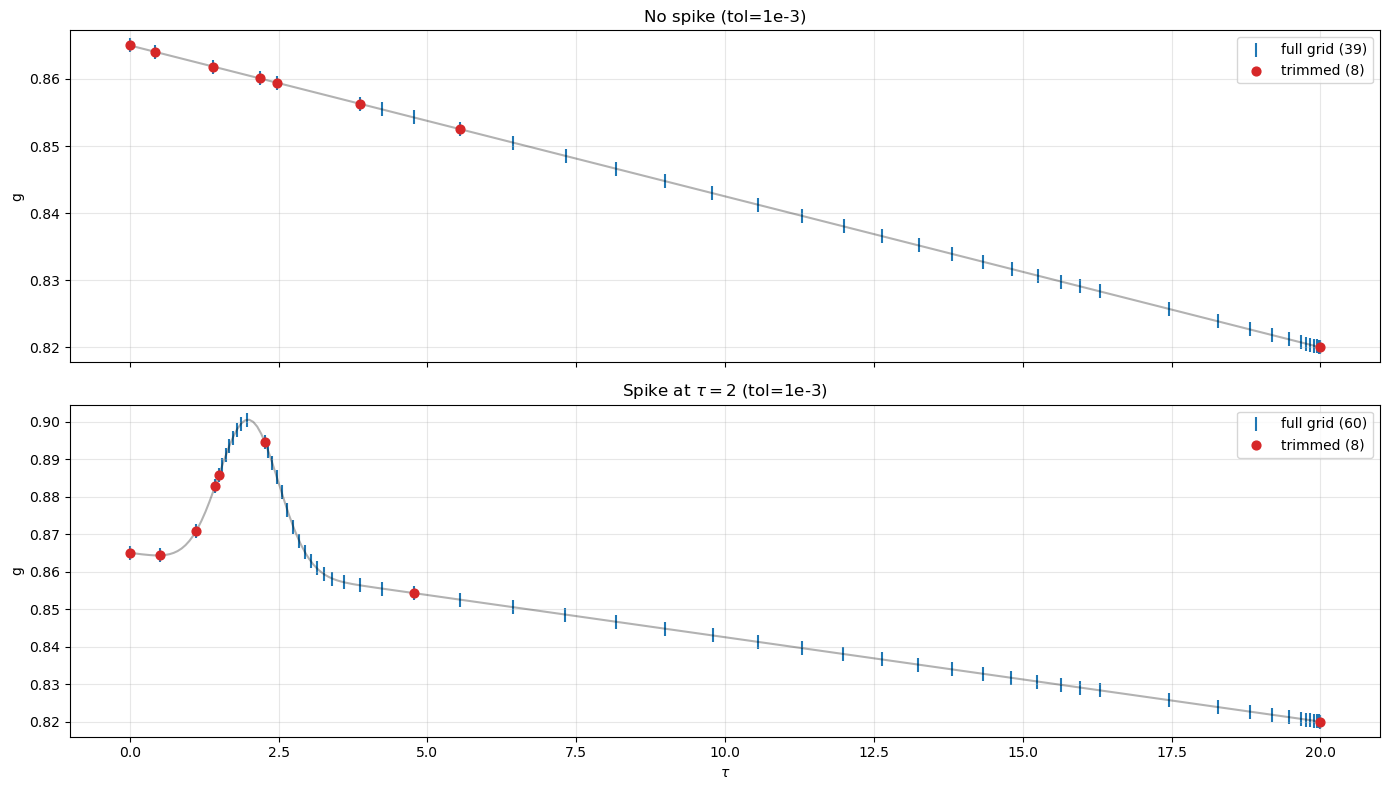

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top panel: no-spike
ax = axes[0]
ax.plot(tau_plot, g_func(tau_plot), 'k-', alpha=0.3)
ax.scatter(tau_grid_J_nospike, g_func(jnp.array(tau_grid_J_nospike)),
           marker='|', s=100, color=plt_default_colors[0], label=f"full grid ({len(tau_grid_J_nospike)})")
ax.scatter(tau_grid_J_nospike[sel_nospike], g_func(jnp.array(tau_grid_J_nospike[sel_nospike])),
           marker='o', s=40, color=plt_default_colors[3], zorder=5, label=f"trimmed ({len(sel_nospike)})")
ax.set_ylabel("g")
ax.set_title("No spike (tol=1e-3)")
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom panel: spike
ax = axes[1]
ax.plot(tau_plot, g_func_spike(tau_plot), 'k-', alpha=0.3)
ax.scatter(tau_grid_J_spike, g_func_spike(jnp.array(tau_grid_J_spike)),
           marker='|', s=100, color=plt_default_colors[0], label=f"full grid ({len(tau_grid_J_spike)})")
ax.scatter(tau_grid_J_spike[sel_spike], g_func_spike(jnp.array(tau_grid_J_spike[sel_spike])),
           marker='o', s=40, color=plt_default_colors[3], zorder=5, label=f"trimmed ({len(sel_spike)})")
ax.set_ylabel("g")
ax.set_xlabel(r"$\tau$")
ax.set_title(rf"Spike at $\tau={tau_spike:g}$ (tol=1e-3)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()